In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict

In [2]:
root_path = '/Users/mariana/Documents/col/lts4/survan/Results'
dataset = 'mimic'
# dataset = 'churn_lastfm_months'
# dataset = 'big_rw_100epochs'
# dataset = 'big_rw'
# dataset = 'churn_lastfm_days'

In [3]:
# sa_is_path = os.path.join(root_path, f"SA/{dataset}/transformer/lambda_0.95/landmark_False")
# sa_lm_path = os.path.join(root_path, f"DeepLambdaSA/{dataset}/transformer/lambda_1.0/landmark_True")
# dl_00_path = os.path.join(root_path, f"DeepLambdaSA/{dataset}/transformer/lambda_0.0/landmark_True")
# dl_90_path = os.path.join(root_path, f"DeepLambdaSA/{dataset}/transformer/lambda_0.9/landmark_True")
# dl_95_path = os.path.join(root_path, f"DeepLambdaSA/{dataset}/transformer/lambda_0.95/landmark_True")

sa_is_path = os.path.join(root_path, f"SA/{dataset}/transformer/lambda_0.9/landmark_False")
sa_lm_path = os.path.join(root_path, f"SA/{dataset}/transformer/lambda_0.9/landmark_True")
dl_00_path = os.path.join(root_path, f"DeepLambdaSA/{dataset}/transformer/lambda_0.0/landmark_True")
dl_90_path = os.path.join(root_path, f"DeepLambdaSA/{dataset}/transformer/lambda_0.9/landmark_True")
dl_95_path = os.path.join(root_path, f"DeepLambdaSA/{dataset}/transformer/lambda_0.95/landmark_True")

paths = [sa_is_path, sa_lm_path, dl_95_path, dl_90_path, dl_00_path]

In [4]:
names = ['SA-IS', 'SA-LM', 'DTCSR(0.95)', 'DTCSR(0.9)', 'DTCSR(0.0)']

In [5]:
# Function to process a result.json file
def process_result_file(file_path):
    with open(file_path, 'r') as json_file:
        data = json.load(json_file)
        if 'ci' in data:
            ci = data['ci']
        if 'bs' in data:
            bs = data['bs']
    return ci, bs

In [6]:
res = defaultdict(dict)

# Iterate through all subdirectories and files
cis_, bss_ = [], []
for path, name in zip(paths, names):
    cis, bss = [], []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file == 'results.json':
                file_path = os.path.join(root, file)
                ci, bs = process_result_file(file_path)
                cis.append(ci)
                bss.append(bs)
    cis = np.array(cis)
    bss = np.array(bss)
    cis_.append(cis)
    bss_.append(bss)
    # res[path] = {'ci_mu': cis.mean(), 'ci_std': cis.std(), 'bs_mu': bss.mean(),
    #              'bs_std': bss.std()}
    res[name] = {'ci': cis,
                 'bs': bss}

In [7]:
file

'state.pt'

In [8]:
keys
data.keys()

NameError: name 'keys' is not defined

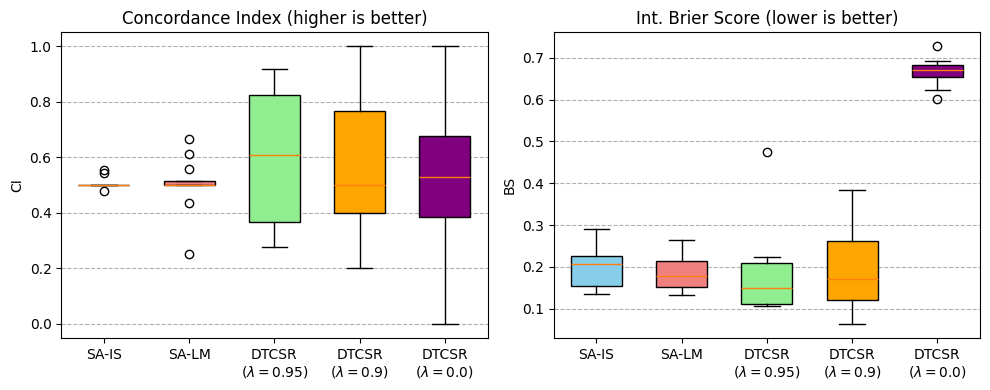

In [9]:
data = res

# Extract keys and values
keys = list(data.keys())

# Add line breaks to the longer labels
keys_with_linebreaks = ['SA-IS', 'SA-LM', 'DTCSR\n($\\lambda=0.95$)', 'DTCSR\n($\\lambda=0.9$)', 'DTCSR\n($\\lambda=0.0$)']

ci_values = [data[key]['ci'] for key in keys]
bs_values = [data[key]['bs'] for key in keys]

# Define colors for each method
colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple']

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Plot for 'ci' values (Boxplots)
box_ci = axs[0].boxplot(ci_values, patch_artist=True, positions=range(len(keys)), widths=0.6)

for patch, color in zip(box_ci['boxes'], colors):
    patch.set_facecolor(color)

axs[0].set_title('Concordance Index (higher is better)')
axs[0].set_ylabel('CI')
axs[0].set_xticks(range(len(keys)))
axs[0].set_xticklabels(keys_with_linebreaks)
axs[0].grid(True, axis='y', linestyle='--')

# Plot for 'bs' values (Boxplots)
box_bs = axs[1].boxplot(bs_values, patch_artist=True, positions=range(len(keys)), widths=0.6)

for patch, color in zip(box_bs['boxes'], colors):
    patch.set_facecolor(color)

axs[1].set_title('Int. Brier Score (lower is better)')
axs[1].set_ylabel('BS')
axs[1].set_xticks(range(len(keys_with_linebreaks)))
axs[1].set_xticklabels(keys_with_linebreaks)
axs[1].grid(True, axis='y', linestyle='--')

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

In [10]:
datasets = ['mimic', 'churn_lastfm_months', 'nasa', 'big_rw']
paths_d = {}

for dataset in datasets:

    sa_is_path = os.path.join(root_path, f"SA/{dataset}/transformer/lambda_0.9/landmark_False")
    sa_lm_path = os.path.join(root_path, f"SA/{dataset}/transformer/lambda_0.9/landmark_True")
    dl_00_path = os.path.join(root_path, f"DeepLambdaSA/{dataset}/transformer/lambda_0.0/landmark_True")
    dl_90_path = os.path.join(root_path, f"DeepLambdaSA/{dataset}/transformer/lambda_0.9/landmark_True")
    dl_95_path = os.path.join(root_path, f"DeepLambdaSA/{dataset}/transformer/lambda_0.95/landmark_True")

    paths = [sa_is_path, sa_lm_path, dl_95_path, dl_90_path, dl_00_path]
    paths_d[dataset] = paths

In [11]:
names = ['SA-IS', 'SA-LM', 'DTCSR(0.95)', 'DTCSR(0.9)', 'DTCSR(0.0)']

In [12]:
# Function to process a result.json file
def process_result_file(file_path):
    with open(file_path, 'r') as json_file:
        data = json.load(json_file)
        if 'ci' in data:
            ci = data['ci']
        if 'bs' in data:
            bs = data['bs']
    return ci, bs

In [13]:
res = defaultdict(lambda: defaultdict(dict))

for dataset in datasets:
    paths = paths_d[dataset]
    for path, name in zip(paths, names):
        cis, bss = [], []
        for root, dirs, files in os.walk(path):
            for file in files:
                if file == 'results.json':
                    file_path = os.path.join(root, file)
                    ci, bs = process_result_file(file_path)
                    cis.append(ci)
                    bss.append(bs)
        
        cis = np.array(cis)
        bss = np.array(bss)
        res[dataset][name] = {'ci': cis,
                              'bs': bss}

In [14]:
res['big_rw']['DTCSR(0.0)']

{'ci': array([0.89828285]), 'bs': array([0.16671649])}

In [15]:
res['nasa']['SA-LM']

{'ci': array([0.65775401, 0.61736334, 0.62204724, 0.56909091, 0.79296875,
        0.74736842, 0.74011299, 0.56976744, 0.5880829 , 0.72695035,
        0.70535714, 0.75483871, 0.61094225, 0.65886288, 0.56      ,
        0.62      , 0.64204545, 0.62857143, 0.5951417 , 0.65187713,
        0.57272727, 0.61827957, 0.61878453, 0.63128492, 0.61061947,
        0.70521173, 0.64179104, 0.60309278, 0.65141956, 0.64663462,
        0.60855263]),
 'bs': array([0.18078735, 0.14891838, 0.15155771, 0.16433442, 0.09729314,
        0.11938162, 0.11480623, 0.11725341, 0.16132757, 0.15930125,
        0.13421433, 0.10712705, 0.12958255, 0.15361723, 0.11862689,
        0.12540236, 0.12450761, 0.19573832, 0.1648514 , 0.13964586,
        0.16428623, 0.15204906, 0.1319259 , 0.11276781, 0.18899365,
        0.14191818, 0.13538155, 0.09826826, 0.11365223, 0.14075933,
        0.16588448])}

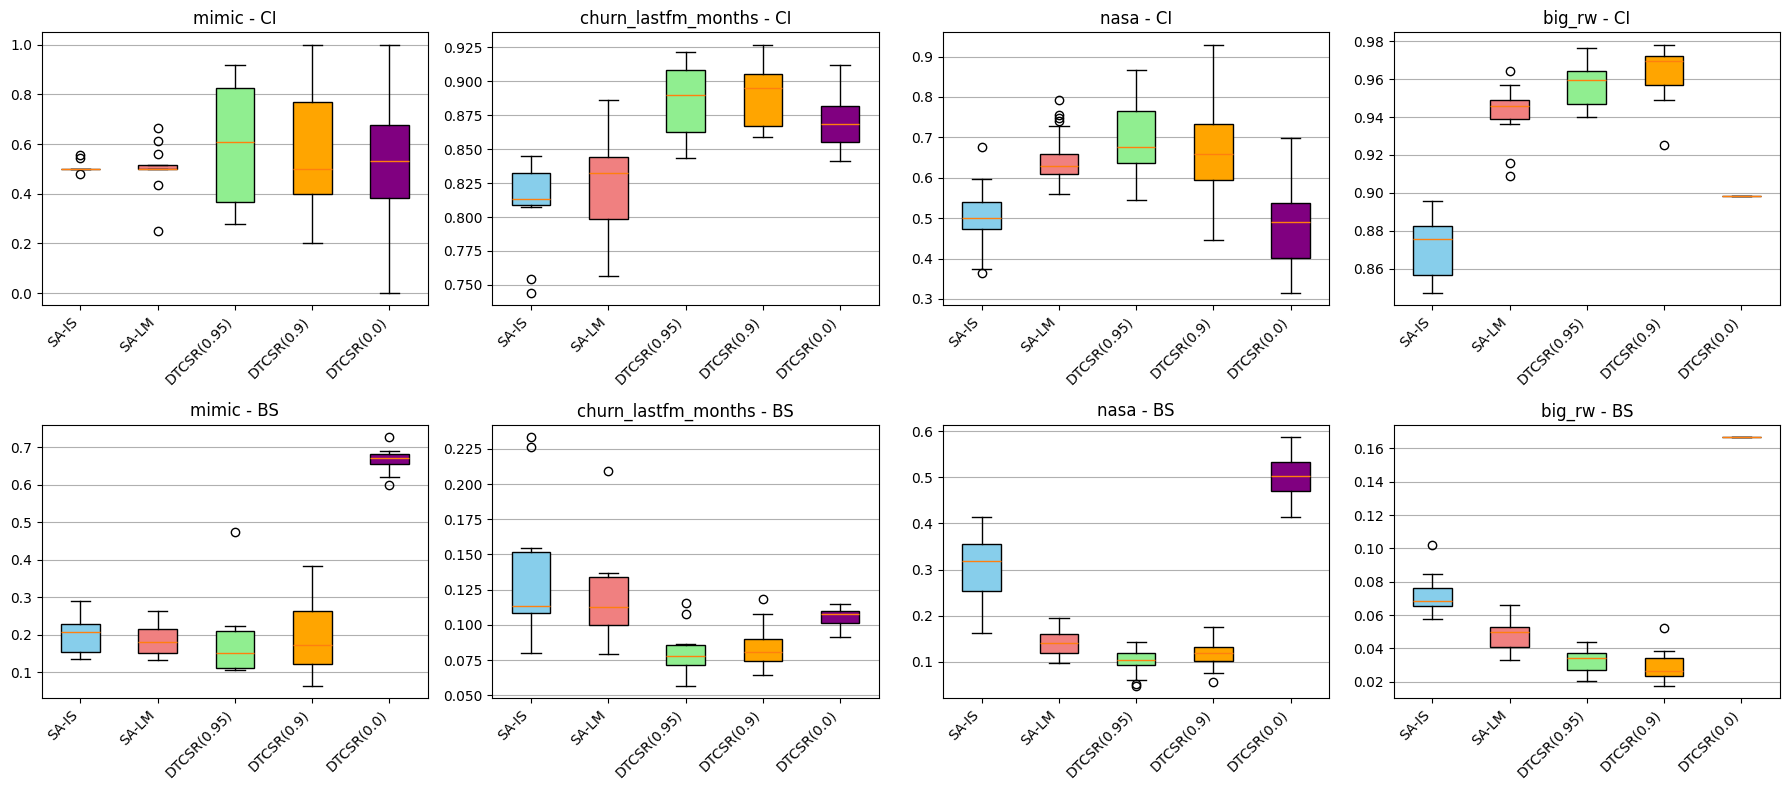

In [16]:
colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple']

# Create a figure with two rows of subplots
fig, axes = plt.subplots(2, len(res), figsize=(18, 8))

# Iterate over datasets
for col, (dataset, methods) in enumerate(res.items()):
    ci_data = [metrics['ci'] for metrics in methods.values()]
    bs_data = [metrics['bs'] for metrics in methods.values()]
    method_names = list(methods.keys())

    # Plot CI boxplots in the upper row
    box = axes[0, col].boxplot(ci_data, patch_artist=True)
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    axes[0, col].set_title(f'{dataset} - CI')
    axes[0, col].set_xticklabels(method_names, rotation=45, ha='right')
    axes[0, col].grid(axis='y')

    # Plot BS boxplots in the bottom row
    box = axes[1, col].boxplot(bs_data, patch_artist=True)
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    axes[1, col].set_title(f'{dataset} - BS')
    axes[1, col].set_xticklabels(method_names, rotation=45, ha='right')
    axes[1, col].grid(axis='y')
    
# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [17]:
# For each dataset, each method, and each metric (CI and BS), conduct a t-test to check if the difference for each metric between methods is statistically significant

from scipy.stats import ttest_ind

# Define a significance level
alpha = 0.05

# # Iterate over datasets
# for dataset, methods in res.items():
#     print(f'\nDataset: {dataset}')
#     for metric in ['ci', 'bs']:
#         print(f'\nMetric: {metric}')
#         for i, (name1, data1) in enumerate(methods.items()):
#             for j, (name2, data2) in enumerate(methods.items()):
#                 if i < j:
#                     _, p_value = ttest_ind(data1[metric], data2[metric])
#                     if p_value < alpha:
#                         print(f'The difference between {name1} and {name2} is statistically significant (p-value: {p_value:.4f})')
#                     else:
#                         print(f'The difference between {name1} and {name2} is not statistically significant (p-value: {p_value:.4f})')

# Do the same as above but pick the best method for each dataset and metric according to the mean value that is statistically significantly better than the others.
# Store mean and std for each method and metric in a dictionary

# Define a significance level
alpha = 0.05

ttests = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Iterate over datasets
for dataset, methods in res.items():
    for metric in ['ci', 'bs']:
        for i, (name1, data1) in enumerate(methods.items()):
            for j, (name2, data2) in enumerate(methods.items()):
                if i < j:
                    _, p_value = ttest_ind(data1[metric], data2[metric])
                    if p_value < alpha:
                        ttests[dataset][metric]['significant'].append((name2, name1))
                    else:
                        ttests[dataset][metric]['not_significant'].append((name2, name1))

# Convert all lists to sets
for dataset, metrics in ttests.items():
    for metric, methods in metrics.items():
        for key, value in methods.items():
            ttests[dataset][metric][key] = set(value)

In [18]:
dataset = 'big_rw'

In [19]:
ttests[dataset]['ci']

defaultdict(list,
            {'significant': {('DTCSR(0.0)', 'DTCSR(0.9)'),
              ('DTCSR(0.0)', 'DTCSR(0.95)'),
              ('DTCSR(0.0)', 'SA-LM'),
              ('DTCSR(0.9)', 'SA-IS'),
              ('DTCSR(0.9)', 'SA-LM'),
              ('DTCSR(0.95)', 'SA-IS'),
              ('DTCSR(0.95)', 'SA-LM'),
              ('SA-LM', 'SA-IS')},
             'not_significant': {('DTCSR(0.0)', 'SA-IS'),
              ('DTCSR(0.9)', 'DTCSR(0.95)')}})

In [20]:
ttests[dataset]['bs']

defaultdict(list,
            {'significant': {('DTCSR(0.0)', 'DTCSR(0.9)'),
              ('DTCSR(0.0)', 'DTCSR(0.95)'),
              ('DTCSR(0.0)', 'SA-IS'),
              ('DTCSR(0.0)', 'SA-LM'),
              ('DTCSR(0.9)', 'SA-IS'),
              ('DTCSR(0.9)', 'SA-LM'),
              ('DTCSR(0.95)', 'SA-IS'),
              ('DTCSR(0.95)', 'SA-LM'),
              ('SA-LM', 'SA-IS')},
             'not_significant': {('DTCSR(0.9)', 'DTCSR(0.95)')}})

In [21]:
# Now I need to collect the mean and std for each method and metric. This should be very simple to do. Let's put results in a nested dictionary of the same structure as above

# Collect mean and std for each method and metric
results = defaultdict(lambda: defaultdict(dict))

# Iterate over datasets
for dataset, methods in res.items():
    for method, metrics in methods.items():
        for metric, values in metrics.items():
            results[dataset][method][metric] = {'mean': values.mean(), 'std': values.std()}


In [22]:
results

defaultdict(<function __main__.<lambda>()>,
            {'mimic': defaultdict(dict,
                         {'SA-IS': {'ci': {'mean': 0.5064945060149663,
                            'std': 0.020410848885279567},
                           'bs': {'mean': 0.20032994076609612,
                            'std': 0.047928126004122946}},
                          'SA-LM': {'ci': {'mean': 0.5017819929904329,
                            'std': 0.0958726875179219},
                           'bs': {'mean': 0.18758848930398622,
                            'std': 0.0416416517720889}},
                          'DTCSR(0.95)': {'ci': {'mean': 0.5980622552051124,
                            'std': 0.24415701506443316},
                           'bs': {'mean': 0.1962637198822839,
                            'std': 0.12121591816458305}},
                          'DTCSR(0.9)': {'ci': {'mean': 0.5767573696145124,
                            'std': 0.25812106228020903},
                           'bs'